In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kankanachakraborty/fake-news/true.csv
/kaggle/input/datasets/kankanachakraborty/fake-news/fake.csv


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1783499531.319758      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


Training RNN Model...
Epoch 1/15


I0000 00:00:1783499531.322627      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  3/562 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.4896 - loss: 0.6939

I0000 00:00:1783499536.618574     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


562/562 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.5092 - loss: 0.7035 - val_accuracy: 0.4950 - val_loss: 0.6931
Epoch 2/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.5131 - loss: 0.6941 - val_accuracy: 0.6105 - val_loss: 0.6904
Epoch 3/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.5160 - loss: 0.6932 - val_accuracy: 0.5344 - val_loss: 0.6914
Epoch 4/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.5113 - loss: 0.6966 - val_accuracy: 0.6205 - val_loss: 0.6909
Epoch 5/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.6295 - loss: 0.6475 - val_accuracy: 0.6508 - val_loss: 0.6304
Epoch 6/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.6472 - loss: 0.6377 - val_accuracy: 0.6493 - val_loss: 0.6370
Epoch 7/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.6454 - loss: 0.6380 - val_accuracy: 0.6497 - val_loss: 0.6325
Epoch 8/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.5947 - loss: 0.6609 - val_accurac

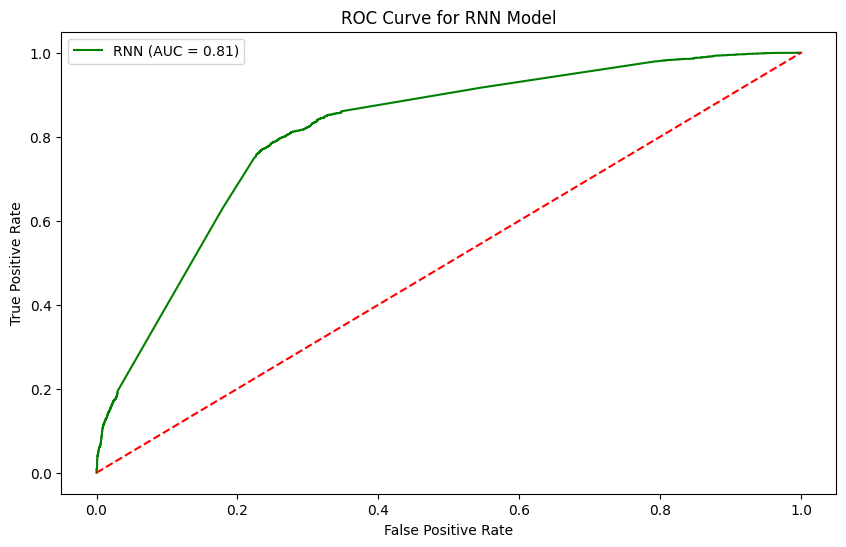

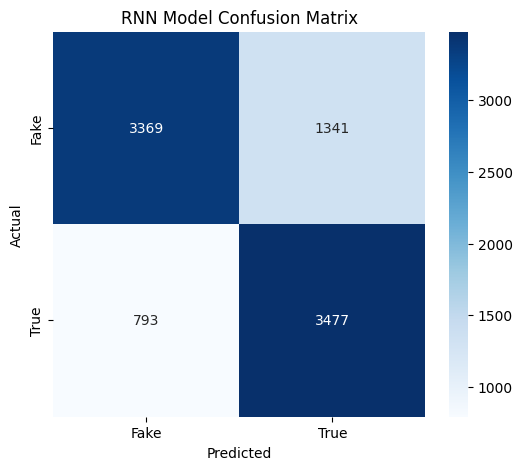

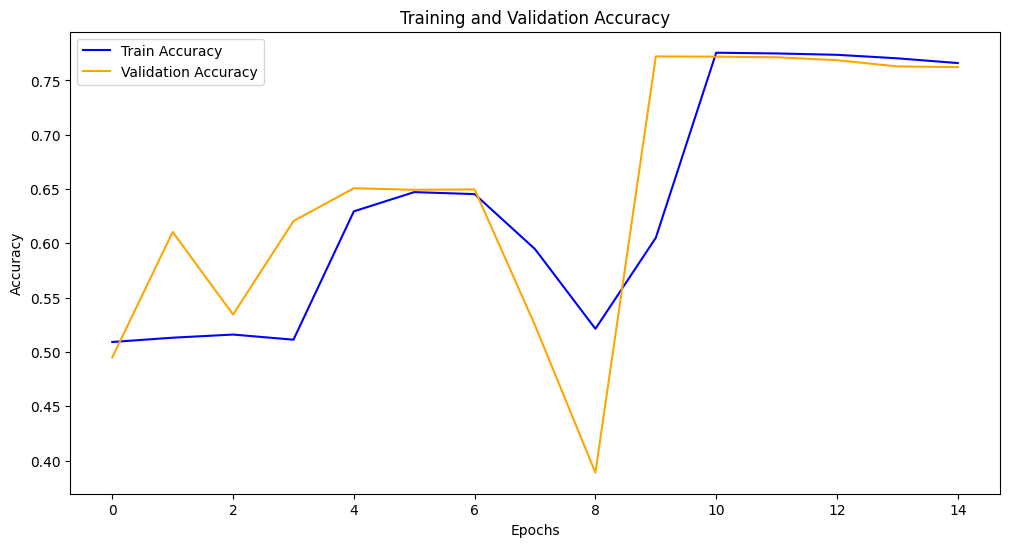

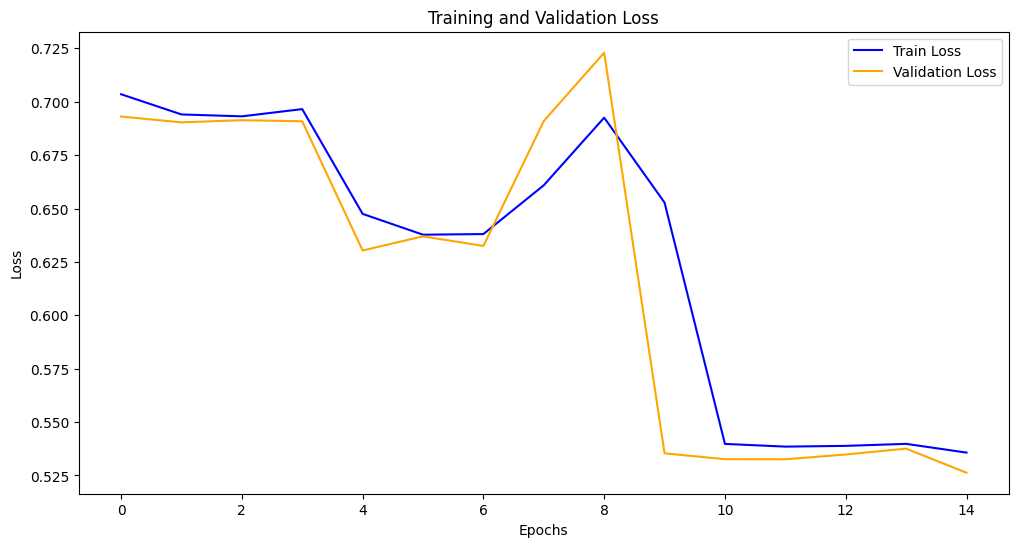

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
fake_df = pd.read_csv('/kaggle/input/datasets/kankanachakraborty/fake-news/fake.csv')
true_df = pd.read_csv('/kaggle/input/datasets/kankanachakraborty/fake-news/true.csv')

# Add labels: 0 for fake, 1 for true
fake_df['label'] = 0
true_df['label'] = 1

# Combine datasets
data = pd.concat([fake_df, true_df], ignore_index=True)
data = data[['text', 'label']]

# Shuffle the dataset
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# Prepare inputs (text) and outputs (labels)
X = data['text']
y = data['label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=500, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=500, padding='post', truncating='post')

# Build the RNN model using SimpleRNN
rnn_model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=500),  # Embedding Layer
    SimpleRNN(64, return_sequences=False),  # SimpleRNN Layer with 64 units
    Dropout(0.5),  # Dropout Layer to prevent overfitting
    Dense(64, activation='relu'),  # Fully connected Dense Layer
    Dropout(0.5),  # Dropout Layer
    Dense(1, activation='sigmoid')  # Output Layer with sigmoid activation for binary classification
])

# Compile the model
# Loss function: Binary Crossentropy (for binary classification)
# Optimizer: Adam (Adaptive Moment Estimation for better optimization)
# Metrics: Accuracy
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
print("Training RNN Model...")
rnn_history = rnn_model.fit(X_train_padded, y_train,
                            epochs=15,  # Increased epochs to 15
                            batch_size=64,
                            validation_data=(X_test_padded, y_test))

# Evaluate the model
y_pred_rnn = rnn_model.predict(X_test_padded).ravel()
y_pred_rnn_class = (y_pred_rnn > 0.5).astype(int)

# Performance metrics
print("\nRNN Model Performance:")
print(classification_report(y_test, y_pred_rnn_class))

# Plot ROC Curve and AUC
fpr_rnn, tpr_rnn, _ = roc_curve(y_test, y_pred_rnn)
roc_auc_rnn = auc(fpr_rnn, tpr_rnn)

plt.figure(figsize=(10, 6))
plt.plot(fpr_rnn, tpr_rnn, label=f'RNN (AUC = {roc_auc_rnn:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for RNN Model')
plt.legend()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rnn_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.title(f'RNN Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Optional: Plot Training and Validation Accuracy/Loss over Epochs
plt.figure(figsize=(12, 6))
plt.plot(rnn_history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(rnn_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(rnn_history.history['loss'], label='Train Loss', color='blue')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [3]:
# Save SimpleRNN model, tokenizer, preprocessing settings, history, and metrics

from pathlib import Path
import json
import numpy as np
from sklearn.metrics import classification_report

SAVE_DIR = Path("saved_models")


def make_json_safe(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, dict):
        return {key: make_json_safe(val) for key, val in value.items()}
    if isinstance(value, list):
        return [make_json_safe(item) for item in value]
    return value


def save_models(rnn_model, tokenizer, rnn_history=None, save_dir=SAVE_DIR):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    model_path = save_dir / "rnn_fake_news_model.keras"
    tokenizer_path = save_dir / "rnn_tokenizer.json"
    config_path = save_dir / "rnn_preprocessing_config.json"
    history_path = save_dir / "rnn_training_history.json"
    metrics_path = save_dir / "rnn_model_metrics.json"

    rnn_model.save(str(model_path))

    with open(tokenizer_path, "w", encoding="utf-8") as f:
        f.write(tokenizer.to_json())

    preprocessing_config = {
        "model_type": "SimpleRNN",
        "num_words": tokenizer.num_words,
        "maxlen": X_train_padded.shape[1],
        "padding": "post",
        "truncating": "post",
        "oov_token": tokenizer.oov_token,
        "threshold": 0.5,
        "class_labels": {
            "0": "Fake",
            "1": "True"
        }
    }

    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(preprocessing_config, f, indent=4)

    saved_files = {
        "rnn_model": str(model_path),
        "tokenizer": str(tokenizer_path),
        "preprocessing_config": str(config_path)
    }

    if rnn_history is not None:
        with open(history_path, "w", encoding="utf-8") as f:
            json.dump(make_json_safe(rnn_history.history), f, indent=4)
        saved_files["training_history"] = str(history_path)

    metrics = {
        "classification_report": classification_report(
            y_test,
            y_pred_rnn_class,
            output_dict=True
        ),
        "roc_auc": roc_auc_rnn,
        "confusion_matrix": cm,
        "fpr": fpr_rnn,
        "tpr": tpr_rnn
    }

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(make_json_safe(metrics), f, indent=4)

    saved_files["metrics"] = str(metrics_path)

    print("SimpleRNN model and preprocessing files saved successfully.")
    return saved_files


saved_rnn_files = save_models(rnn_model, tokenizer, rnn_history)
saved_rnn_files


SimpleRNN model and preprocessing files saved successfully.


{'rnn_model': 'saved_models/rnn_fake_news_model.keras',
 'tokenizer': 'saved_models/rnn_tokenizer.json',
 'preprocessing_config': 'saved_models/rnn_preprocessing_config.json',
 'training_history': 'saved_models/rnn_training_history.json',
 'metrics': 'saved_models/rnn_model_metrics.json'}